<a id="top"></a>
# Chapter 6 — Benchmarking, numerics, fitting and the MemrisTec library

**MemrisTec Compact Models — Memristor Physics from Paper to Code** · chapter 6 of 6

[◀ 5 Pulses, retention and neuromorphic use](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [Contents of the book](README.md)

**In this chapter**

- [§21 Four models, one stimulus](#sec-21)
- [§22 Numerics: step size and integrator](#sec-22)
- [§23 Fitting a model to a measurement](#sec-23)
- [§24 Cross-check against the MemrisTec Model Library](#sec-24)
- [§25 Where compact models stop: the rest of the library](#sec-25)
- [§26 Contributing to MemrisTec](#sec-26)

All chapters: [0](Memristec_00_Introduction.ipynb) · [1](Memristec_01_State_Controlled_Resistor.ipynb) · [2](Memristec_02_Linear_Ion_Drift_and_Windows.ipynb) · [3](Memristec_03_Threshold_Switching_VTEAM.ipynb) · [4](Memristec_04_Filamentary_Switching.ipynb) · [5](Memristec_05_Pulses_and_Neuromorphic_Use.ipynb) · [6](Memristec_06_Benchmarking_and_the_Library.ipynb)

*Every notebook runs on its own: the setup cell below is identical in all of them. Section numbers (§1–26), figure numbers and cross-references are global to the book.*

In [1]:
# ---- shared setup: this cell is identical in every chapter of the book ----------
import os
import sys
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, HTML

# the toolkit lives in scripts/ at the repository root (chapters/ is one level down);
# build/execute.py --outdir runs a copy elsewhere and names the root in MEMRISTEC_SKILL_ROOT
for _cand in ("scripts", os.path.join("..", "scripts"),
              os.path.join(os.environ.get("MEMRISTEC_SKILL_ROOT", ""), "scripts")):
    if os.path.isfile(os.path.join(_cand, "memristec_tools.py")):
        sys.path.insert(0, os.path.abspath(_cand))
        break
import memristec_tools as mt
from memristec_tools import (LinearIonDrift, Yakopcic2013, VTEAM2015, StanfordPKU2016, MODELS,
                             simulate, iv_sweep, loop_metrics, dynamic_route_map,
                             pulse_train, pulse_response, sine, triangular, rectangular)

plt.rcParams.update({"figure.dpi": 100, "figure.figsize": (7.0, 4.0), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
warnings.filterwarnings("ignore", category=RuntimeWarning)

_CHECKS = {"pass": 0, "fail": 0}
_FIG = {"n": 21}               # figure numbers run through the whole book

def check(label, ok, detail=""):
    '''Inline physics check; prints PASS/FAIL and tallies for the final summary.'''
    ok = bool(ok)
    _CHECKS["pass" if ok else "fail"] += 1
    print(f"[{'PASS' if ok else 'FAIL'}] {label}" + (f" — {detail}" if detail else ""))
    return ok

def caption(text):
    '''Numbered caption rendered directly below the figure it describes.'''
    _FIG["n"] += 1
    display(HTML(
        f"<div style='max-width:780px;margin:2px 0 14px 12px;font-size:0.92em;"
        f"color:#444;border-left:3px solid #bbb;padding-left:10px'>"
        f"<b>Figure {_FIG['n']}.</b> {text}</div>"))

def show(fig):
    '''Display a figure and close it (keeps the notebook small).'''
    plt.show()
    plt.close(fig)

print("memristec-skill", mt.__version__, "| numpy", np.__version__, "| chapter 6")
t_chapter_start = time.time()

memristec-skill 0.2.1 | numpy 2.5.2 | chapter 6


<a id="sec-21"></a>

## 21. Four models, one stimulus

Benchmarking compact models means driving them with the *same* stimulus and reading the same
descriptors. `loop_metrics` returns the lobe area, the extreme currents, the pinching flag and
the extreme resistances; the table below lists them for the four shipped models under a 1.5 V,
1 Hz sine, and the figure overlays the loops normalised to their own peak current so that
their shapes — lens, switch, snap — can be compared regardless of scale.

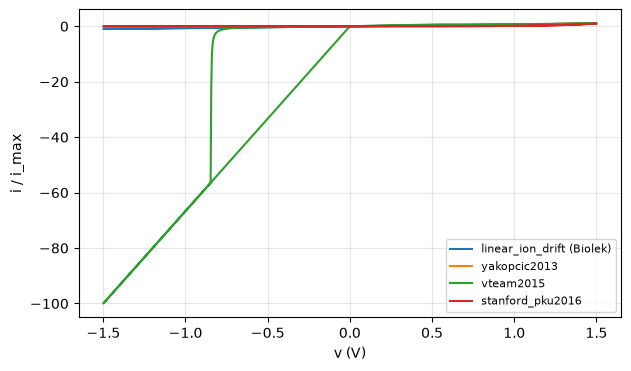

linear_ion_drift (Biolek)    area=1.86e-05 V·A  i_max=6.14e-05 A  pinched=True  x∈[0.26,0.46]
yakopcic2013                 area=3.70e-04 V·A  i_max=1.28e-02 A  pinched=True  x∈[0.00,1.00]
vteam2015                    area=3.51e-04 V·A  i_max=1.50e-05 A  pinched=True  x∈[0.00,1.00]
stanford_pku2016             area=1.79e-05 V·A  i_max=4.07e-03 A  pinched=True  x∈[0.00,1.00]
[PASS] every loop is pinched at the origin
[PASS] the filamentary model has the largest on/off ratio


True

In [2]:
bench = {"linear_ion_drift (Biolek)": (LinearIonDrift(window="biolek", R_off=38e3, x0=0.26), 4000),
         "yakopcic2013": (Yakopcic2013(), 4000), "vteam2015": (VTEAM2015(), 4000),
         "stanford_pku2016": (StanfordPKU2016(), 20000)}
rows, results = [], {}
fig, ax = plt.subplots()
for name, (m, n) in bench.items():
    r = iv_sweep(m, 1.5, 1.0, cycles=1, n_per_cycle=n)
    met = loop_metrics(r); results[name] = met
    rows.append(f"{name:<28s} area={met['area']:.2e} V·A  i_max={met['i_max']:.2e} A  "
                f"pinched={met['pinched_at_origin']}  x∈[{r.x.min():.2f},{r.x.max():.2f}]")
    step = max(1, n // 2000)
    ax.plot(r.v[::step], r.i[::step] / met["i_max"], label=name)
ax.set_xlabel("v (V)"); ax.set_ylabel("i / i_max"); ax.legend(fontsize=8)
show(fig)
caption("The four shipped models under one 1.5 V, 1 Hz sine, each loop normalised to its own "
        "peak current: the smooth lens of linear ion drift, Yakopcic's exponential turn-on, "
        "VTEAM's switch between two straight lines, the filamentary snap of Stanford–PKU.")
print("\n".join(rows))
check("every loop is pinched at the origin", all(m["pinched_at_origin"] for m in results.values()))
check("the filamentary model has the largest on/off ratio", results["stanford_pku2016"]["r_max"] / results["stanford_pku2016"]["r_min"]
      > results["vteam2015"]["r_max"] / results["vteam2015"]["r_min"] > 1.0)

<a id="sec-22"></a>

## 22. Numerics: step size and integrator

Every result in this book comes from a fixed-step integrator on the stimulus grid. The
question "how many points per period" has a measurable answer: integrate the Yakopcic device
with Euler and RK4 at 200, 500 and 2000 points per period and compare with a 20 000-point
reference. Both errors fall with the step; RK4's falls faster and is at the 0.3 % level at
2 000 points, which is why that is the driver's default. The stiff Stanford–PKU model needs
ten times more (`references/pitfalls.md`). A variable-step solver (`method="ivp"`) is
available but, with the maximum step tied to the grid, it is slower and not more accurate
here.

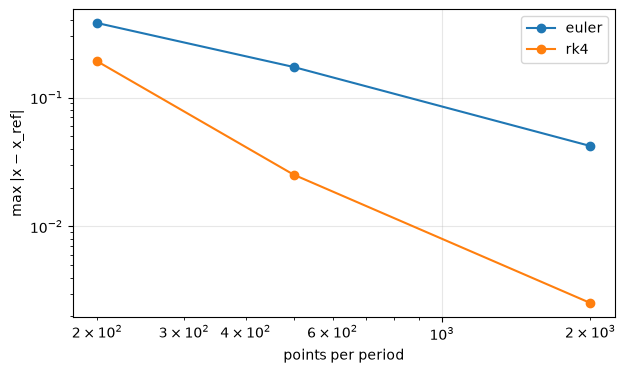

{'euler': ['3.78e-01', '1.73e-01', '4.20e-02'], 'rk4': ['1.91e-01', '2.52e-02', '2.54e-03']}
[PASS] RK4 beats Euler at every step size
[PASS] RK4 at 2 000 points per period is accurate to 1 % in x — 2.54e-03
[PASS] RK4 converges faster than Euler from 500 to 2 000 points


True

In [3]:
ref = iv_sweep(Yakopcic2013(), 1.0, 1.0, cycles=1, n_per_cycle=20000)
ns = [200, 500, 2000]
errors = {"euler": [], "rk4": []}
for n in ns:
    for meth in errors:
        r = iv_sweep(Yakopcic2013(), 1.0, 1.0, cycles=1, n_per_cycle=n, method=meth)
        errors[meth].append(float(np.max(np.abs(np.interp(ref.t, r.t, r.x) - ref.x))))
fig, ax = plt.subplots()
for meth, errs in errors.items():
    ax.loglog(ns, errs, "o-", label=meth)
ax.set_xlabel("points per period"); ax.set_ylabel("max |x − x_ref|"); ax.legend()
show(fig)
caption("Maximum state error of the Yakopcic device against a 20 000-point RK4 reference for "
        "Euler and RK4 at 200, 500 and 2 000 points per period (1 V, 1 Hz sine).")
print({k: [f"{e:.2e}" for e in v] for k, v in errors.items()})
check("RK4 beats Euler at every step size", all(r < e for r, e in zip(errors["rk4"], errors["euler"])))
check("RK4 at 2 000 points per period is accurate to 1 % in x", errors["rk4"][-1] < 0.01, f"{errors['rk4'][-1]:.2e}")
check("RK4 converges faster than Euler from 500 to 2 000 points",
      errors["rk4"][1] / errors["rk4"][2] > errors["euler"][1] / errors["euler"][2])

<a id="sec-23"></a>

## 23. Fitting a model to a measurement

A compact model earns its keep when its parameters can be extracted from a measured I-V curve.
The recipe is ordinary least squares on the current: simulate with trial parameters, subtract
the data, let `scipy.optimize.least_squares` adjust. The cell fits two VTEAM parameters
($k_{\rm off}$, $v_{\rm off}$) to a *synthetic* measurement generated with known values, so the
answer is known: the fit recovers them to machine precision in a dozen evaluations. Real data
adds noise, drift and unknown initial states — the fitting workflow for the owner's TaO$_x$
device (`references/fitting.md`, planned) builds on this cell.

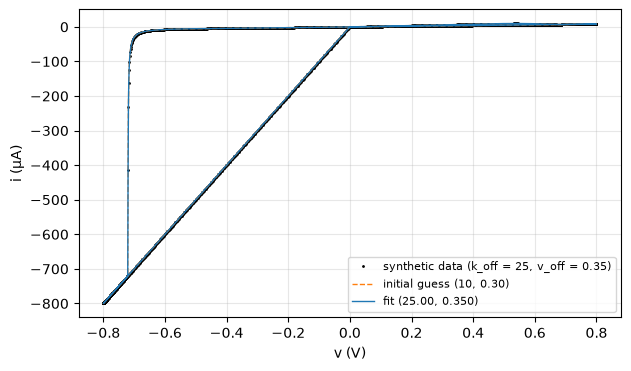

fit: k_off = 24.999988, v_off = 0.350000; 12 evaluations, 2.4 s, cost 1.4e-18
[PASS] k_off recovered to 0.1 %
[PASS] v_off recovered to 1 mV


True

In [4]:
from scipy.optimize import least_squares

truth = dict(k_off=25.0, v_off=0.35)
data = iv_sweep(VTEAM2015(**truth), 0.8, 1.0, cycles=1, n_per_cycle=2000)
scale = np.max(np.abs(data.i))

def residual(p):
    r = iv_sweep(VTEAM2015(k_off=p[0], v_off=p[1]), 0.8, 1.0, cycles=1, n_per_cycle=2000)
    return (r.i - data.i) / scale

t0 = time.time()
sol = least_squares(residual, x0=[10.0, 0.30], bounds=([0.1, 0.05], [200.0, 0.7]), diff_step=1e-3)
fit = iv_sweep(VTEAM2015(k_off=sol.x[0], v_off=sol.x[1]), 0.8, 1.0, cycles=1, n_per_cycle=2000)
start = iv_sweep(VTEAM2015(k_off=10.0, v_off=0.30), 0.8, 1.0, cycles=1, n_per_cycle=2000)

fig, ax = plt.subplots()
ax.plot(data.v, 1e6 * data.i, "k.", ms=2, label="synthetic data (k_off = 25, v_off = 0.35)")
ax.plot(start.v, 1e6 * start.i, "C1--", lw=1, label="initial guess (10, 0.30)")
ax.plot(fit.v, 1e6 * fit.i, "C0", lw=1, label=f"fit ({sol.x[0]:.2f}, {sol.x[1]:.3f})")
ax.set_xlabel("v (V)"); ax.set_ylabel("i (µA)"); ax.legend(fontsize=8)
show(fig)
caption("Least-squares fit of the VTEAM rate k_off and threshold v_off to a synthetic 0.8 V, 1 Hz "
        "loop: the initial guess, the data and the fitted loop, which lies on the data.")
print(f"fit: k_off = {sol.x[0]:.6f}, v_off = {sol.x[1]:.6f}; {sol.nfev} evaluations, {time.time() - t0:.1f} s, cost {sol.cost:.1e}")
check("k_off recovered to 0.1 %", abs(sol.x[0] - 25.0) < 0.025)
check("v_off recovered to 1 mV", abs(sol.x[1] - 0.35) < 1e-3)

<a id="sec-24"></a>

## 24. Cross-check against the MemrisTec Model Library

`scripts/upstream_adapter.py` imports a model folder of a *local clone* of the library, wraps
its derivative and current in our interface, and `crosscheck` compares the two derivative
fields on a grid of $(x, v)$. The tolerances live in `tests/records/crosscheck_v1.json`. This
is how every equation set in this book was verified against the library's implementation —
and how finding P-1 (the folder named Biolek implements the Joglekar window) was measured. The
cell needs `MEMRISTEC_MODEL_LIBRARY` to point at the clone; without it, it prints `[SKIP]` and
draws nothing. Nothing from the clone is copied here; the notebook only reports numbers.

HP_Biolek2009  max rel |Δ dx/dt| = 4.0e-16 (tol 1e-09)   max rel |Δ i| = 0.0e+00 (tol 1e-12)   ok
Stanford_PKU   max rel |Δ dx/dt| = 0.0e+00 (tol 1e-09)   max rel |Δ i| = 0.0e+00 (tol 1e-12)   ok
VTEAM2015      max rel |Δ dx/dt| = 2.0e-16 (tol 1e-09)   max rel |Δ i| = 2.1e-16 (tol 1e-12)   ok
Yakopcic2013   max rel |Δ dx/dt| = 0.0e+00 (tol 1e-09)   max rel |Δ i| = 0.0e+00 (tol 1e-12)   ok
[PASS] every shimmed folder matches our clean-room model within its recorded tolerance


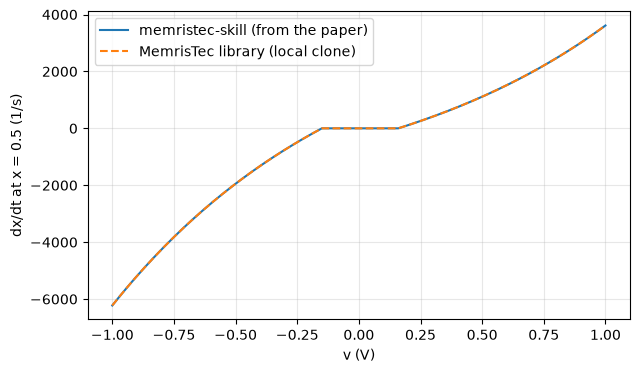

In [5]:
import json
import upstream_adapter as ua

LIB = ua.find_library()
if LIB is None:
    print("[SKIP] MEMRISTEC_MODEL_LIBRARY is not set — cross-check not run in this execution")
else:
    with open(os.path.join(os.path.dirname(mt.__file__), "..", "tests", "records", "crosscheck_v1.json"), encoding="utf-8") as f:
        records = json.load(f)["models"]
    x_grid = np.linspace(0.02, 0.98, 25)
    v_grids = {"HP_Biolek2009": np.linspace(-1.2, 1.2, 13), "Yakopcic2013": np.linspace(-1.0, 1.0, 21),
               "VTEAM2015": np.concatenate([np.linspace(-1.0, -0.35, 8), np.linspace(0.35, 1.0, 8)]),
               "Stanford_PKU": np.linspace(-1.5, 1.5, 21)}
    ok_all = True
    for name in sorted(ua.SHIMS):
        theirs = ua.load_upstream(name, LIB)
        ours = ua.OURS[name](theirs.params)
        r = ua.crosscheck(ours, theirs, x_grid, v_grids[name])
        tol = records[name]
        ok = r["max_rel_dxdt"] <= tol["max_rel_dxdt"] and r["max_rel_i"] <= tol["max_rel_i"]
        ok_all &= ok
        print(f"{name:<14s} max rel |Δ dx/dt| = {r['max_rel_dxdt']:.1e} (tol {tol['max_rel_dxdt']:.0e})   "
              f"max rel |Δ i| = {r['max_rel_i']:.1e} (tol {tol['max_rel_i']:.0e})   {'ok' if ok else 'DIFFERS'}")
    check("every shimmed folder matches our clean-room model within its recorded tolerance", ok_all)
    theirs = ua.load_upstream("Yakopcic2013", LIB); ours = Yakopcic2013(**theirs.params)
    vs = np.linspace(-1.0, 1.0, 201)
    fig, ax = plt.subplots()
    ax.plot(vs, [ours.state_derivative(0.5, v) for v in vs], label="memristec-skill (from the paper)")
    ax.plot(vs, [theirs.state_derivative(0.5, v) for v in vs], "--", label="MemrisTec library (local clone)")
    ax.set_xlabel("v (V)"); ax.set_ylabel("dx/dt at x = 0.5 (1/s)"); ax.legend()
    show(fig)
    caption("The Yakopcic derivative field at x = 0.5 from our clean-room model and from the "
            "library's own code running in a local clone: the two curves coincide.")

<a id="sec-25"></a>

## 25. Where compact models stop: the rest of the library

The MemrisTec Model Library on its `main` branch holds sixteen model folders (thirteen with
code). This book re-derives the four families that have a published, complete equation set and
that the library implements as a single-state ODE; the study repository's audit records the
per-folder decision. The rest:

| folder | why it is not (yet) a clean-room model here |
|---|---|
| `JART_VCM_v1_simplified`, `JART_VCM_varV1_Simplified` | Jülich–Aachen VCM model (Bengel et al. 2020, *IEEE TCAS-I*; the folders' own json cites the JART ECM paper of 2024 instead — finding P-7): several coupled equations with Schottky and plug/disc resistances; the planned fitting target for a TaO$_x$ device — next |
| `Threshold_Switching_KumarWilliams2017`, `…_Simplified2020`, `…_PickettWilliams_Simplified2022` | thermal (temperature-state) NbO$_2$ threshold switches: volatile, current-controlled NDR; papers to read before transcription |
| `Threshold_Switching_Pershin2013`, `TUD_Schroedter_2022` | no DOI in the folder / implicit current equation; adapter-only |
| `DataDriven2021` | a data-driven model built on a measured dataset (Southampton), not on an equation set |
| `HP_Joglekar2009`, `MEMMEA2025`, `Threshold_Switching_PickettWilliams2012` | metadata only (`model.json`), no code upstream |
| `HP_Prodromakis2011` | covered by the `prodromakis` window of `linear_ion_drift` |

**Data-driven models** replace the equation set by an interpolation of measured transitions;
they reproduce one device family well and say nothing outside the measured range. **Thermal
models** make the temperature the state and add the heat balance $C_{\rm th}\dot T = i v -
(T - T_{\rm amb})/R_{\rm th}$: they are the natural home of volatility. Both are reachable now
through the adapter from your clone; neither is shipped.

In [6]:
print("clean-room models in memristec-skill:", sorted(MODELS))
print("adapter shims (need a local clone):  ", sorted(ua.SHIMS))
if LIB is not None:
    folders = sorted(d for d in os.listdir(os.path.join(LIB, "models")) if os.path.isdir(os.path.join(LIB, "models", d)))
    print(f"folders in the clone's models/: {len(folders)}")
check("four clean-room models and four shims", len(MODELS) == 4 and len(ua.SHIMS) == 4)

clean-room models in memristec-skill: ['linear_ion_drift', 'stanford_pku2016', 'vteam2015', 'yakopcic2013']
adapter shims (need a local clone):   ['HP_Biolek2009', 'Stanford_PKU', 'VTEAM2015', 'Yakopcic2013']
folders in the clone's models/: 16
[PASS] four clean-room models and four shims


True

<a id="sec-26"></a>

## 26. Contributing to MemrisTec

Everything this book measured against the library is a candidate contribution, and the study
repository keeps the ledger (`docs/02-findings-backlog.md`): **P** items are upstream defects
found by running the code (P-1: the "Biolek" folder implements Joglekar's window; P-2: the
Yakopcic `simulate` ignores its voltage argument; P-6: the Stanford runner calls an undefined
class), **B** items are proposals (B-1: a licence file — without one, no framework can legally
import the models the README says it targets; B-2: a shared `state_derivative` / `current`
interface and a `pyproject.toml`), **N** items are our own fixes (N-2: the signed loop area;
N-8: pulse edges on an exact grid).

The rules of the road, from the study's playbook: nothing is sent to the maintainers by an
agent; every text is drafted in `docs/drafts/`, verified on a real run, and filed by the owner
under his name; no line of the library is copied into this product; the adapter is how numbers
are compared. A merge request would carry the licence file, SPDX headers, the packaging file
and the interface — in that order, licence first.

In [7]:
records_path = os.path.join(os.path.dirname(mt.__file__), "..", "tests", "records", "crosscheck_v1.json")
print("memristec-skill", mt.__version__)
print("cross-check records: tests/records/crosscheck_v1.json", "(present)" if os.path.isfile(records_path) else "(MISSING)")
with open(os.path.join(os.path.dirname(mt.__file__), "..", "VERSION"), encoding="utf-8") as f:
    version_file = f.read().strip()
check("this notebook ran on the version it documents", mt.__version__ == version_file and mt.__version__ >= "0.2.0", mt.__version__)
check("the cross-check records ship with the toolkit", os.path.isfile(records_path))

memristec-skill 0.2.1
cross-check records: tests/records/crosscheck_v1.json (present)
[PASS] this notebook ran on the version it documents — 0.2.1
[PASS] the cross-check records ship with the toolkit


True

### Exercises for chapter 6

**6.1** Add 1 % Gaussian noise (relative to the peak current) to the synthetic data of §23 and
refit. How far do the recovered parameters move — and why? Then choose a drive under which the
parameters *are* identifiable and refit.

**6.2** Repeat §22 with `method="ivp"` at 2 000 points per period. Is it closer to the
reference than RK4, and how long does it take?

In [8]:
# 6.1 — measured: the 0.8 V drive of §23 switches the device fully for the guess and for the
#       truth alike, so the two parameter sets differ only in a few transient points: the cost
#       between guess and truth (2e-5) is 4 000× below the noise floor (0.5 · 2001 · 0.01² ≈ 0.1)
#       and the noisy fit wanders off. The parameters are not identifiable from that experiment.
#       A 0.5 V drive switches the device only partially (x ∈ [0.33, 0.72]): the same noise then
#       leaves v_off within 1 % and k_off within 10 % (the threshold sets where the loop opens,
#       the rate only how fast — a weaker signature).
rng = np.random.default_rng(7)
noisy = data.i + 0.01 * scale * rng.standard_normal(len(data.i))
floor = 0.5 * np.sum(((noisy - data.i) / scale) ** 2)
gap = 0.5 * np.sum(residual([10.0, 0.30]) ** 2)
def residual_noisy(p):
    r = iv_sweep(VTEAM2015(k_off=p[0], v_off=p[1]), 0.8, 1.0, cycles=1, n_per_cycle=2000)
    return (r.i - noisy) / scale
sol_n = least_squares(residual_noisy, x0=[10.0, 0.30], bounds=([0.1, 0.05], [200.0, 0.7]), diff_step=1e-3)
check("6.1 at 0.8 V the guess-to-truth cost is < 1 % of the noise floor: the parameters are not identifiable",
      gap / floor < 1e-2, f"cost gap {gap:.1e} vs noise floor {floor:.2e}; noisy fit k_off = {sol_n.x[0]:.2f}, v_off = {sol_n.x[1]:.4f}")

data_05 = iv_sweep(VTEAM2015(**truth), 0.5, 1.0, cycles=1, n_per_cycle=2000)
scale_05 = np.max(np.abs(data_05.i))
noisy_05 = data_05.i + 0.01 * scale_05 * rng.standard_normal(len(data_05.i))
def residual_05(p):
    r = iv_sweep(VTEAM2015(k_off=p[0], v_off=p[1]), 0.5, 1.0, cycles=1, n_per_cycle=2000)
    return (r.i - noisy_05) / scale_05
sol_05 = least_squares(residual_05, x0=[10.0, 0.30], bounds=([0.1, 0.05], [200.0, 0.7]), diff_step=1e-3)
check("6.1 at 0.5 V (partial switching) the noisy fit recovers v_off within 1 % and k_off within 10 %",
      abs(sol_05.x[1] / 0.35 - 1) < 0.01 and abs(sol_05.x[0] / 25.0 - 1) < 0.10 and 0.3 < data_05.x.min() < data_05.x.max() < 0.75,
      f"k_off = {sol_05.x[0]:.2f}, v_off = {sol_05.x[1]:.4f}; x ∈ [{data_05.x.min():.2f}, {data_05.x.max():.2f}]")

# 6.2
t0 = time.time()
r_ivp = iv_sweep(Yakopcic2013(), 1.0, 1.0, cycles=1, n_per_cycle=2000, method="ivp")
e_ivp = float(np.max(np.abs(r_ivp.x - ref.x[::10])))
check("6.2 ivp at 2 000 points is within 1 % of the reference", e_ivp < 0.01, f"error {e_ivp:.2e}, {time.time() - t0:.1f} s (RK4 error {errors['rk4'][-1]:.2e})")

[PASS] 6.1 at 0.8 V the guess-to-truth cost is < 1 % of the noise floor: the parameters are not identifiable — cost gap 2.2e-05 vs noise floor 9.71e-02; noisy fit k_off = 0.30, v_off = 0.1558


[PASS] 6.1 at 0.5 V (partial switching) the noisy fit recovers v_off within 1 % and k_off within 10 % — k_off = 22.89, v_off = 0.3472; x ∈ [0.33, 0.72]


[PASS] 6.2 ivp at 2 000 points is within 1 % of the reference — error 7.63e-06, 1.1 s (RK4 error 2.54e-03)


True

In [9]:
# ---- tally for this notebook ---------------------------------------------------
print("=" * 66)
print(f"chapter 6 — checks passed : {_CHECKS['pass']}")
print(f"chapter 6 — checks failed : {_CHECKS['fail']}")
print(f"wall time                 : {time.time() - t_chapter_start:.0f} s")
print("=" * 66)
print("Every quantitative claim in this notebook was verified in this run."
      if _CHECKS["fail"] == 0 else "Some checks FAILED — search this notebook for '[FAIL]'.")

chapter 6 — checks passed : 14
chapter 6 — checks failed : 0
wall time                 : 24 s
Every quantitative claim in this notebook was verified in this run.
